# Age and Gender Distortion in Online Media and Large Language Models

Try searching "CEO" and "secretary" on Google. You will notice that the CEOs look older and in most cases male, while the secretaries look younger and female. This is not random, but a systematic pattern embedded in both AI models and online image search results.

A [recent paper in Nature](https://www.nature.com/articles/s41586-025-09581-z) by Bhatia (2025) shows that **the internet does not only show existing stereotypes, but it makes them stronger.** When people search for an occupation online, the images they see show women as younger and men as older than what we would normally expect.

In this notebook we are going to replicate the key findings of the article. We will use GPT-2 Large embeddings and experimental data from image search results to show that age and gender biases exist in AI models, and that these biases carry over into real-world image search. We will use correlation analysis, regression, density plots, t-tests, and ANOVA to confirm that the distortion is real and significant.

## Setup the Scene

We begin by importing the Pandas library, which is the main library used in this notebook for data loading and 
manipulation

In [1]:
import pandas as pd

## Part 1: Exploring the GPT-2 Embeddings

In this part we load the GPT-2 Large embeddings dataset and explore its structure. We want to understand what social categories are included, how many there are and what variables are available. Then we will check if the age and gender scores are correlated and how strong that relationship is.

In [2]:
gpt2_df = pd.read_csv('myData/GPT2-large-dimensions.csv')

In [3]:
gpt2_df.head()

,Social.Category,Source,gender.main,gender_norm.main,gender.ext,gender_norm.ext,gender.red,gender_norm.red,age.main,age_norm.main,age.ext,age_norm.ext,age.red,age_norm.red
0,abandoned infant,GPT2,-0.197087,0.540877,0.001662,0.527162,-0.108243,0.561858,-0.070237,0.357426,-0.004732,0.319985,-0.055446,0.419423
1,abandoned person,GPT2,-0.199134,0.535577,0.001236,0.523567,-0.110507,0.554830,-0.065570,0.382294,-0.001178,0.343708,-0.048989,0.477159
2,abiogenist,GPT2,-0.231156,0.452671,0.004317,0.549545,-0.151075,0.428889,-0.097012,0.214761,-0.026444,0.175097,-0.063784,0.344863
3,able-bodied seaman,GPT2,-0.162948,0.629264,0.001341,0.524456,-0.067956,0.686928,-0.042036,0.507690,0.016286,0.460250,-0.043687,0.524568
4,able seaman,GPT2,-0.181426,0.581424,0.002330,0.532793,-0.089043,0.621465,-0.055517,0.435856,0.006879,0.397472,-0.049394,0.473540


In [4]:
gpt2_df.shape

(3495, 14)

In [5]:
gpt2_df.columns

Index(['Social.Category', 'Source', 'gender.main', 'gender_norm.main',
       'gender.ext', 'gender_norm.ext', 'gender.red', 'gender_norm.red',
       'age.main', 'age_norm.main', 'age.ext', 'age_norm.ext', 'age.red',
       'age_norm.red'],
      dtype='str')

The dataset contains **3,495 social categories** (like "abandoned infant", "able seaman", etc.) and **14 columns**. Each category has a gender and an age score measured in three different ways (main, ext, red), along with their normalized versions. The normalized scores range from 0 to 1. Higher values mean the category is more associated with being male or being older respectively. We will use the **main** normalized scores (`gender_norm.main` and `age_norm.main`) for most of our analysis.

### Correlation between Age and Gender

The first question we want to answer is whether the age and gender scores in GPT-2 are associated. If they are, it means that the model links being male with being older and being female with being younger. For this purpose we will use the Pearson correlation to measure this.

In [6]:
import pingouin as pg

# Pearson correlation between the main gender and age scores
pg.corr(gpt2_df['gender.main'], gpt2_df['age.main'])

,n,r,CI95,p_val,BF10,power
pearson,3495,0.872559,"[0.86, 0.88]",0.0,inf,1.0


From the results we observe that there was a strong positive correlation between the gender and age, *r*(3493) = .87, *p* < .001, 95% CI [.86, .88].

This means that social categories that GPT-2 associates with being more male are also associated with being older, and the other way around. The Bayes Factor is infinite, which means the data overwhelmingly supports the existence of this relationship over the null hypothesis. The statistical power is 1.0, meaning we had more than enough data to detect this effect.

GPT-2 treats gender and age as connected. Social categories that it sees as more male, it also sees as older. Social categories that it sees as more female, it also sees as younger. The two biases go hand in hand.

### Do the Three Extraction Methods Agree?

Age and gender scores were each extracted using three different methods (main, ext and red). To make sure our results do not depend on which method we use, we calculate all pairwise correlations between the three variants and display them as heatmaps. If the correlations are high across all pairs, it means the results are robust and consistent regardless of the extraction method.

In [7]:
# Extract the three variants for age and gender
ages = gpt2_df[['age.red', 'age.ext', 'age.main']]
genders = gpt2_df[['gender.red', 'gender.ext', 'gender.main']]

We create two separate dataframes, one for age and one for gender, each containing the three variants (main, ext, red). Then we compute the Pearson correlation between every pair of variants.

In [8]:
# Compute pairwise correlations within each age and gender
ages_corr = ages.corr()
gender_corr = genders.corr()

Now we visualize the correlation matrices as heatmaps. If all values are close to 1, it means the three methods agree with each other and produce similar results.

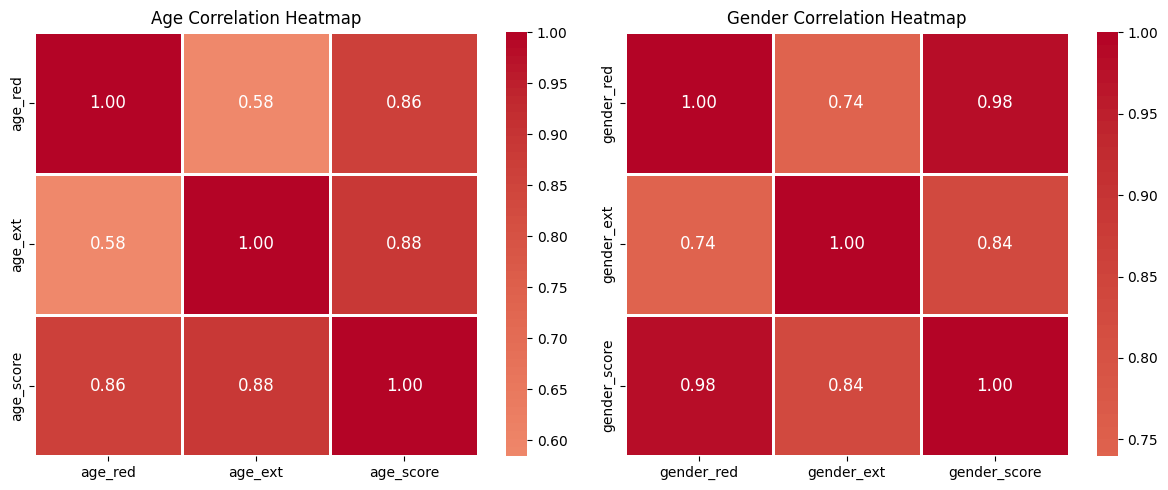

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two heatmaps side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Age heatmap
# coolwarm colormap (blue = low correlation, red = high correlation)
# annot=True shows the correlation values inside each cell
sns.heatmap(
    ages_corr,
    cmap='coolwarm',
    annot=True,
    fmt='.2f',
    annot_kws={'size': 12},
    vmin=-1,
    vmax=1,
    xticklabels=['age_red', 'age_ext', 'age_score'],
    yticklabels=['age_red', 'age_ext', 'age_score'],
    ax=ax1,
    linecolor='white',
    linewidths=1
)
ax1.set_title('Age Correlation Heatmap', loc='center')
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=90, va='center')
# Adjust colorbar range to match actual data values
colorbar1 = ax1.collections[0].colorbar
colorbar1.ax.set_ylim(ages_corr.min().min(), ages_corr.max().max())

# Gender heatmap (same structure as above)
sns.heatmap(
    gender_corr,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    xticklabels=['gender_red', 'gender_ext', 'gender_score'],
    yticklabels=['gender_red', 'gender_ext', 'gender_score'],
    annot=True,
    annot_kws={'size': 12},
    fmt='.2f',
    linewidths=1,
    linecolor='white',
    ax=ax2
)
ax2.set_title('Gender Correlation Heatmap', loc='center')
ax2.set_yticklabels(ax2.get_yticklabels(), rotation=90, va='center')
colorbar2 = ax2.collections[0].colorbar
colorbar2.ax.set_ylim(gender_corr.min().min(), gender_corr.max().max())

plt.tight_layout()
plt.show()

All correlations are above 0.58 for age and above 0.74 for gender. The strongest agreement is between the red and main methods (0.86 for age, 0.98 for gender), while the ext method shows slightly lower but still strong correlations. This is consistent with the article, which states that the results are 'highly robust' to varying the technique used for extracting the age and gender scores (Supplementary Fig. 13). Since all three methods agree, our findings do not depend on the specific extraction method used.

We can also look at all six variables together in a single heatmap. This lets us see not only how the three variants agree within age and within gender, but also how age and gender relate to each other across all methods.

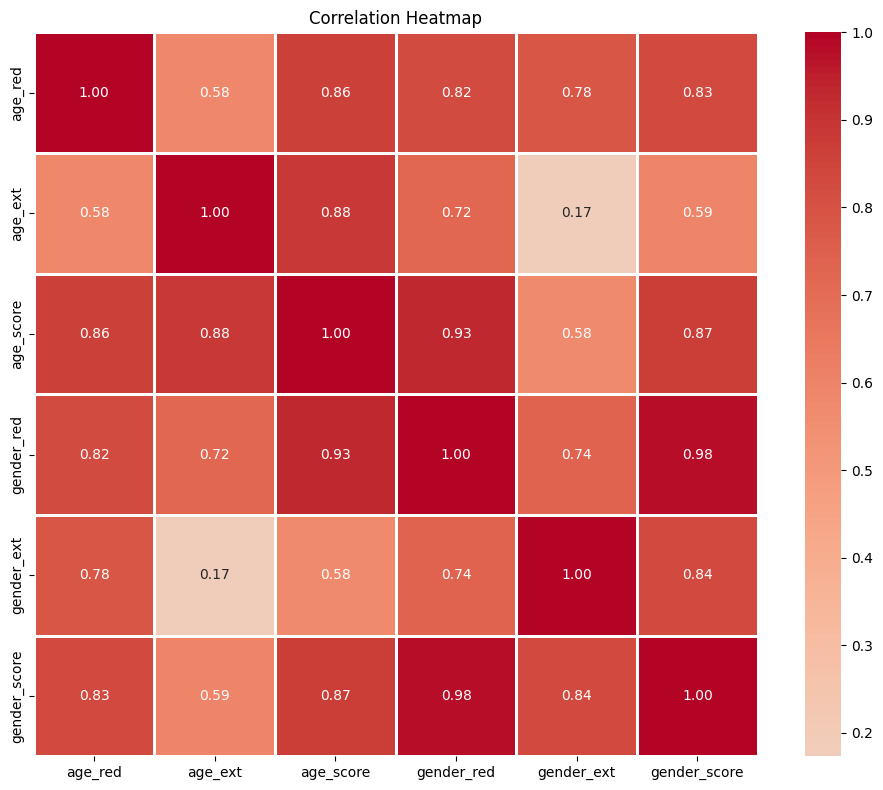

In [10]:
# Combine all six variables into one correlation matrix
all_scores = gpt2_df[['age.red', 'age.ext', 'age.main', 'gender.red', 'gender.ext', 'gender.main']]
all_corr = all_scores.corr()

fig, ax = plt.subplots(figsize=(10, 8))

# Single heatmap with all age and gender
sns.heatmap(
    all_corr,
    cmap='coolwarm',
    annot=True,
    fmt='.2f',
    annot_kws={'size': 10},
    vmin=-1,
    vmax=1,
    square=True,
    xticklabels=['age_red', 'age_ext', 'age_score', 'gender_red', 'gender_ext', 'gender_score'],
    yticklabels=['age_red', 'age_ext', 'age_score', 'gender_red', 'gender_ext', 'gender_score'],
    linecolor='white',
    linewidths=1,
    ax=ax
)
ax.set_yticklabels(ax.get_yticklabels(), rotation=90, va='center')
ax.set_title('Correlation Heatmap')

# Adjust colorbar range to match actual data values
colorbar = ax.collections[0].colorbar
colorbar.ax.set_ylim(all_corr.min().min(), all_corr.max().max())

plt.tight_layout()
plt.show()

The combined heatmap shows two important things. First, within each group the three variants are strongly correlated (top-left block for age, bottom-right block for gender), confirming what we saw in the separate heatmaps. Second, the correlations between the groups (top-right and bottom-left blocks) show that age and gender are positively associated across almost all method combinations, with most values above 0.70. The strongest association between the different groups is between age_score and gender_red (0.93), while the weakest is between age_ext and gender_ext (0.17). The ext method appears to be the least consistent overall, but it does not change the overall finding. The association between age and gender holds regardless of which extraction method we use.

### From Correlation to Prediction: OLS Regression

The correlation showed us that age and gender are associated, but we want to go further. We fit an Ordinary Least Squares regression to model how well the gender score predicts the age score. This lets us quantify the strength of the relationship and get a regression line we can plot later.

Before we look at the results, it helps to understand what `gender_norm_main` and `age_norm_main` actually are. According to the article, these scores are constructed from GPT-2 Large's internal word embeddings using a method called the **"geometry of culture"**. Each social category is placed on a scale based on how close it is to a "female pole" or a "male pole" in the embedding space. This raw score is then **normalized across all 3,495 categories**, so that:

- `gender_norm_main`: **0 = most female, 1 = most male** (relative to all other categories)
- `age_norm_main`: **0 = most young, 1 = most old** (relative to all other categories)

The scores are not absolute ages or gender labels, but they show where each category sits **relative to all others**.

$$\text{age\_norm\_main} = \beta_0 + \beta_1 \cdot \text{gender\_norm\_main} + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma^2)$$

In [11]:
# statsmodels formulas do not support dots in variable names
gpt2_df = gpt2_df.rename(columns={'age_norm.main': 'age_norm_main', 'gender_norm.main': 'gender_norm_main'})

In [12]:
import statsmodels.formula.api as smf

# age_norm_main dependent variable 
# gender_norm_main independent variable 
gender_age_mod = smf.ols(formula="age_norm_main ~ gender_norm_main", data=gpt2_df)
gender_age_res = gender_age_mod.fit()
gender_age_res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          age_norm_main   R-squared:                       0.761
Model:                            OLS   Adj. R-squared:                  0.761
Method:                 Least Squares   F-statistic:                 1.114e+04
Date:                Sun, 22 Mar 2026   Prob (F-statistic):               0.00
Time:                        20:48:20   Log-Likelihood:                 5425.6
No. Observations:                3495   AIC:                        -1.085e+04
Df Residuals:                    3493   BIC:                        -1.083e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -0.0211      0.003     -6.510      0.000      -0.027      -0.015
gender_norm_main     0.7450      0.007    105.565      0.000       0.731       0.759
==============================================================================
Omnibus:                      829.901   Durbin-Watson:                   1.255
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4643.267
Skew:                           1.012   Prob(JB):                         0.00
Kurtosis:                       8.271   Cond. No.                         9.75
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

$$\text{age\_norm\_main} = -0.021 + 0.745 \cdot \text{gender\_norm\_main}$$

**Model fit**

- **R-squared = 0.761**: The gender score alone explains 76.1% of the variance in the age score, which is very high for a single-predictor model. The article reports a correlation of *r* = .87, and since *r-squared* = 0.87² ≈ 0.757, our R-squared is consistent with this.
- **F-statistic = 11,140**, *p* < .001: The model is statistically significant, which means that the regression model predicts better than the null model (just predicting the mean)

**What the coefficients tell us**

- **Intercept ($\beta_0$) = -0.021** (*p* < .001): A category at gender score 0 (the most female of all categories) has a predicted age score of approximately 0, meaning it is associated with being the youngest possible.
- **Slope ($\beta_1$) = 0.745** (*p* < .001): For every increase of 0.01 in the gender score, the predicted age score increases by 0.00745. For example, two categories with gender scores of 0.10 and 0.20 differ in their predicted age score by 0.0745, meaning the more male category is seen as noticeably older by the model.

**In conclusion,** knowing where a social category sits on the gender scale lets you predict its age association with high accuracy.

### Visualizing the Bias: Scatter Plot (Figure 2)

The scatter plot below replicates Figure 2 from the [article](https://www.nature.com/articles/s41586-025-09581-z). Each point represents one of the 3,495 social categories. The x-axis shows the gender association score (from female to male) and the y-axis shows the age association score (from young to old), both extracted from GPT-2 Large.

The article shows that categories associated with being more male are also associated with being older (*r* = .87, *p* < .001). Our regression captures this strong positive relationship, explaining 76.1% of the variance in the age score (R-squared = 0.761).

We highlight 10 categories at the extremes, as the authors do in their original figure:
- **Blue dots**: categories strongly associated with male and old (*military personnel*, *chief of staff*, *elected official*, *chairman of the board*, *director of research*)
- **Gold dots**: categories strongly associated with female and young (*intern*, *homoeopath*, *novice*, *secretary*, *cook*)

In [13]:
from plotnine import *

In [14]:
# Define 5 "male and old" and 5 "female and young" categories
male_old_labels = ['military personnel', 'chief of staff', 'elected official',
                   'chairman of the board', 'director of research']
female_young_labels = ['intern', 'homoeopath', 'novice', 'secretary', 'cook']

# Create a class column: M = male/old extreme, W = female/young extreme, N = neutral
gpt2_df['class'] = 'N'
gpt2_df.loc[gpt2_df['Social.Category'].isin(male_old_labels), 'class'] = 'M'
gpt2_df.loc[gpt2_df['Social.Category'].isin(female_young_labels), 'class'] = 'W'

We want to add text labels to the plot so the reader can see real examples of the bias. To avoid overlapping labels, we manually set the position of each label and draw a line from the point to its label.

In [15]:
# Manual label positions so they don't overlap with the scatter points
label_positions = {
    'chairman of the board': (1, 0.9),
    'elected official': (0.8, 0.8),
    'military personnel': (0.5, 0.7),
    'director of research':(1.1, 0.50),
    'chief of staff': (0.90, 0.40),
    'cook': (0.1, 0),
    'homoeopath': (0, 0.20),
    'intern': (-0.1, 0.10),
    'novice': (0.5, 0.10),
    'secretary':(0.40, 0),
}

# Keep only the labeled categories and add their label coordinates
labeled_df = gpt2_df[gpt2_df['class'] != 'N'].copy()
labeled_df['x_label'] = labeled_df['Social.Category'].map(lambda x: label_positions[x][0])
labeled_df['y_label'] = labeled_df['Social.Category'].map(lambda x: label_positions[x][1])

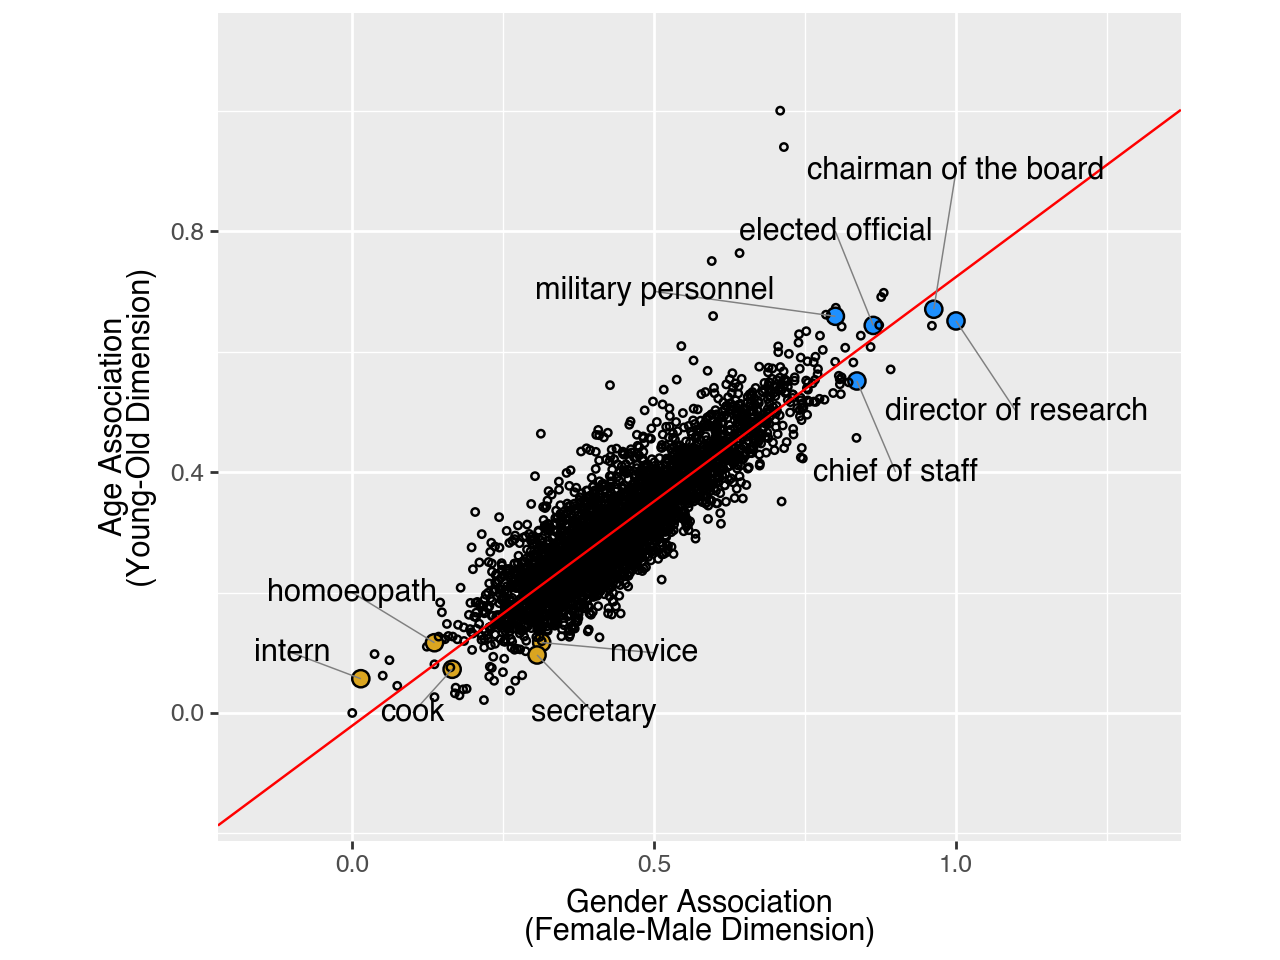

In [16]:
# scatter plot (replicating Figure 2 from the article)
(ggplot(gpt2_df, aes(x='gender_norm_main', y='age_norm_main', fill='class', size='class', alpha='class')) +
    geom_point(shape='o', color='black') +
    scale_fill_manual(values={'M': 'dodgerblue', 'N': 'none', 'W': 'goldenrod'}) +
    scale_size_manual(values={'M': 3, 'N': 1, 'W': 3}) +
    scale_alpha_manual(values={'M': 1, 'N': 1, 'W': 1}) +
    # Regression line from the regression model
    geom_abline(
        intercept=gender_age_res.params['Intercept'],
        slope=gender_age_res.params['gender_norm_main'],
        color='red'
    ) +
    # Lines connecting each labeled point to its label
    geom_segment(
        data=labeled_df,
        mapping=aes(x='gender_norm_main', y='age_norm_main', xend='x_label', yend='y_label'),
        inherit_aes=False,
        color='grey',
        size=0.3
    ) +
    # Text labels 
    geom_text(
        data=labeled_df,
        mapping=aes(x='x_label', y='y_label', label='Social.Category'),
        inherit_aes=False,
        size=11
    ) +
    labs(
        x='Gender Association\n(Female-Male Dimension)',
        y='Age Association\n(Young-Old Dimension)'
    ) +
    theme(legend_position='none', aspect_ratio=0.86) +
    scale_x_continuous(limits=(-0.15, 1.3)) +
    scale_y_continuous(limits=(-0.15, 1.1)))

### Interactive Version

The static plot above highlights 10 extreme categories, but what about the other 3,485? The interactive version below lets you **hover over any point** to see which social category it represents and its exact gender and age scores.

In [17]:
import altair as alt

# Reuse the class column already created above
# Only keep the columns we need and rename them for cleaner tooltips
plot_df = gpt2_df[['Social.Category', 'gender_norm_main', 'age_norm_main', 'class']].copy()
plot_df.columns = ['social_category', 'gender_norm', 'age_norm', 'class']

# Scatter plot with hover tooltips
points = alt.Chart(plot_df).mark_circle(stroke='black', strokeWidth=0.2).encode(
    x=alt.X('gender_norm:Q', title=['Gender Association', '(Female-Male Dimension)'], scale=alt.Scale(domain=[0, 1])),
    y=alt.Y('age_norm:Q', title=['Age Association', '(Young-Old Dimension)'], scale=alt.Scale(domain=[0, 1])),
    color=alt.Color('class:N', scale=alt.Scale(domain=['M', 'N', 'W'], range=['dodgerblue', 'lightgrey', 'goldenrod']), legend=None),
    size=alt.condition(
        alt.datum['class'] == 'N',
        alt.value(30),
        alt.value(110)
    ),
    tooltip=[
        alt.Tooltip('social_category:N', title='Social Category'),
        alt.Tooltip('gender_norm:Q', title='Gender', format='.2f'),
        alt.Tooltip('age_norm:Q', title='Age', format='.2f')
    ]
).properties(width=400, height=400)

# Regression line -> we can either use transform_regression to fit it directly from the data,
# or build it manually using the intercept and slope from our OLS model above.
# Here we use transform_regression for simplicity.
line = alt.Chart(plot_df).transform_regression(
    'gender_norm', 'age_norm'
).mark_line(color='red', strokeWidth=2).encode(
    x='gender_norm:Q',
    y='age_norm:Q'
)

chart = (points + line)
chart

alt.LayerChart(...)

The interactive plot reveals categories that the authors did not highlight, falling into two groups.

The first group are categories that sit far from the regression line. Family terms like *brother-in-law* and *father-in-law* appear much older than predicted simply because the words imply an adult. On the other side, *great grandson* and *granddaughter* appear much younger than predicted because the words suggest a young person. These are not stereotypes but literal age connotations embedded in the language.

The second group are categories that cluster near the blue and gold dots but were not selected. In the male and old corner, categories like *religious person*, *married person* and *cigarette smoker* appear based on social associations. In the female and young corner, *prof*, *captain* and *colonel* appear surprisingly. This is likely because GPT-2 was trained on WebText, which primarily comprises Reddit data. On Reddit, *prof* is used casually by students and picks up associations with younger academics. *Captain* is associated with sports and superhero characters rather than military rank, and *colonel* appears in gaming and popular culture contexts. GPT-2 learns whichever meaning is in the training data.

This is our own observation and goes beyond what the article discusses. It points to a broader limitation of the embedding approach. Words with multiple meanings carry associations that depend on how they are used online, not on what they formally mean.

## Part 2: Does Seeing Images Change How We Think About Age?

So far we have shown that GPT-2 links gender and age together. But does this bias affect real people? The article tests this with a experiment with a nationally representative US sample (n = 459).

Participants were randomly assigned to one of two conditions:

- **Control group**: Participants searched Google Images for unrelated, non-occupation categories (such as apple or guitar). After uploading one of these images, they were asked to estimate the average age of someone in a randomly selected occupation. They were also asked which gender they associate with that occupation.
- **Treatment group**: Participants searched Google Images for specific occupations, uploaded an image of their choice, labelled the gender of the person shown, and then estimated the average age of someone in that occupation.

By comparing the two groups, we can measure how much exposure to occupation images shifts people's age estimates. If image search has no effect, the two groups should give similar estimates.

In [18]:
# Load the data
control_df = pd.read_csv('myData/experiment_control.csv')
treatment_df = pd.read_csv('myData/experiment_treatment.csv')

# Keep only Male and Female participants
treatment_df = treatment_df[treatment_df['gender'].isin(['Male', 'Female'])]

To measure the distortion, we compute the mean age estimated by the control group for each occupation. Then we subtract it from each treatment observation to get the **age relative to control**. A positive value means the treatment participant estimated an older age than the control average, and a negative value means younger.

In [19]:
# Compute the control group's mean age per occupation
control_mean = control_df.groupby('category')['age'].mean().reset_index()
control_mean.columns = ['category', 'control_mean_age']

# Merge with treatment data
age_rel = treatment_df.merge(control_mean, on='category')

# Compute the difference (treatment age - control mean age)
age_rel['diff'] = age_rel['age'] - age_rel['control_mean_age']

# Mean ages by gender in treatment
male_mean = age_rel[age_rel['gender'] == 'Male']['diff'].mean()
female_mean = age_rel[age_rel['gender'] == 'Female']['diff'].mean()
print(f"Male mean age relative to control: {male_mean:.2f} years")
print(f"Female mean age relative to control: {female_mean:.2f} years")

Male mean age relative to control: 0.64 years
Female mean age relative to control: -1.75 years


### Density Plot: Visualizing the Distortion (Figure 3)

To visualize the effect of image search, we compute the age difference for each participant. Specifically, the age difference is the age estimated by each participant in the treatment group for a given occupation, minus the average age estimated for that same occupation by the control group. A positive value means the treatment participant estimated the person to be older than the control average and a negative value means they estimated younger.

We use a Kernel Density Estimation plot to show the full distribution of these age differences, split by the gender of the image uploaded. The vertical dashed line at zero represents no distortion. If image search had no effect, both distributions would be centered on zero.

/Users/tasosrigos/Desktop/Business Analytics/Python for Analytics & AI/.venv/lib/python3.13/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_density : Removed 44 rows containing non-finite values.


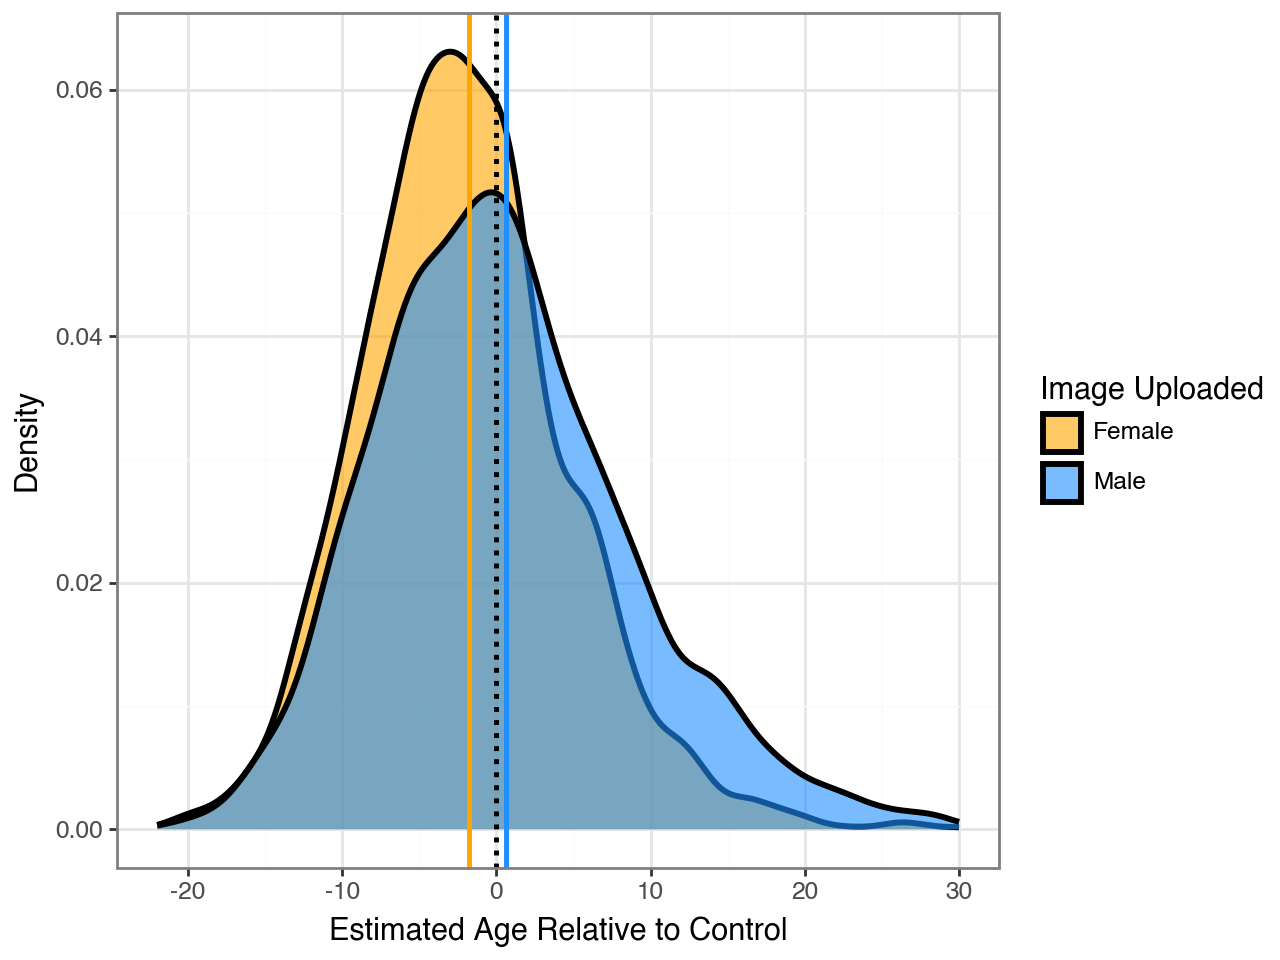

In [20]:
(ggplot(age_rel, aes(x='diff', fill='gender', color='gender')) +
    geom_density(alpha=0.6, color='black', size=1.2) +
    geom_vline(xintercept=0, linetype='dotted', color='black', size=1) +
    geom_vline(xintercept=male_mean, color='dodgerblue', size=1) +
    geom_vline(xintercept=female_mean, color='orange', size=1) +
    scale_fill_manual(values={'Male': 'dodgerblue', 'Female': 'orange'}) +
    labs(
        x='Estimated Age Relative to Control',
        y='Density',
        fill='Image Uploaded',
        color='Image Uploaded'
    ) +
    xlim(-22, 30) +
    theme_bw() +
    theme(panel_border=element_rect(size=1, fill='none'))
)


The KDE plot shows a clear pattern. The female distribution is shifted to the left of zero, meaning participants who uploaded images of women estimated younger ages than the control. The male distribution is shifted to the right, meaning participants who uploaded images of men estimated older ages.

To statistically confirm that these visual differences are significant we run three independent t-tests. Each test asks a specific question about the distortion.

### Test 1: Do women appear younger than men in image search?

We compare the raw age estimates between participants who uploaded a female image and those who uploaded a male image, using an independent samples t-test with unequal variances.

In [21]:
from scipy import stats

male_ages = treatment_df[treatment_df['gender'] == 'Male']['age']
female_ages = treatment_df[treatment_df['gender'] == 'Female']['age']

t, p = stats.ttest_ind(female_ages, male_ages, equal_var=False)
print(f"Mean difference: {female_ages.mean() - male_ages.mean():.2f} years")
print(f"t = {t:.2f}, p = {p:.2e}")

Mean difference: -5.46 years
t = -19.07, p = 5.24e-78


Participants who uploaded an image of a woman estimated the average age of an occupation to be **5.46 years younger** than those who uploaded an image of a man (*t* = -19.07, *p* < .001), replicating the article's finding exactly.

### Test 2: Does seeing a female image make people estimate younger ages than the control?

We now compare the female treatment group against the control baseline for each occupation.

In [22]:
female_diff = age_rel[age_rel['gender'] == 'Female']['diff']

t, p = stats.ttest_1samp(female_diff, 0)
print(f"Mean difference: {female_diff.mean():.2f} years")
print(f"t = {t:.2f}, p = {p:.2e}")

Mean difference: -1.75 years
t = -11.32, p = 4.82e-29


Uploading an image of a woman led participants to estimate the age of an occupation to be **1.75 years younger** than the control group (*t* = -11.32, *p* < .001). Image search pushes estimates below even the baseline expectations people already hold.

### Test 3: Does seeing a male image make people estimate older ages than the control?

We compare the male treatment group against the control baseline.

In [23]:
male_diff = age_rel[age_rel['gender'] == 'Male']['diff']

t, p = stats.ttest_1samp(male_diff, 0)
print(f"Mean difference: {male_diff.mean():.2f} years")
print(f"t = {t:.2f}, p = {p:.2e}")

Mean difference: 0.64 years
t = 3.42, p = 6.37e-04


Uploading an image of a man led participants to estimate the age of an occupation to be **0.64 years older** than the control group (*t* = 3.42, *p* < .001). The effect is smaller than for women, but still significant.

Together, the three tests confirm the article's central finding, which is that image search amplifies age-related gender bias. Women are seen as younger and men as older than what people would otherwise expect, with a combined gap of 5.46 years between the two groups.

## Investigating the Amplification

The three t-tests confirmed that image search distorts age estimates. But they treat each observation independently and do not account for the fact that the same occupations and the same participants appear multiple times. To properly model this, we run an Linear regression using the full combined dataset (treatment and control together).

The article uses this approach to show that the distortion is not just a gender effect or a condition effect in isolation, but that the two interact. In other words, the bias only emerges when you combine being in the treatment condition with the gender of the image seen.

We fit the following model:

$$\text{age} = \beta_0 + \beta_1 \cdot \text{condition} + \beta_2 \cdot \text{gender} + \beta_3 \cdot (\text{condition} \times \text{gender}) + \beta_{\text{category}} + \beta_{\text{subj}} + \epsilon$$

where:
- `condition` captures whether the participant saw an occupation image or not
- `gender` is the gender of the uploaded image (Male as reference level, Treatment coding)
- `condition × gender` is the interaction term, which is the key test
- `category` and `subj` control for occupation-level and individual-level differences

### Preparing the Combined Dataset

In [24]:
combined_df = pd.concat([
    control_df[['category', 'subj', 'age', 'condition', 'gender']],
    treatment_df[['category', 'subj', 'age', 'condition', 'gender']]
], ignore_index=True)

combined_df = combined_df[combined_df['gender'].isin(['Male', 'Female'])]

We combine the two datasets and keep only participants who uploaded a Male or Female image. We also set Male as the reference level so that all coefficients are interpreted relative to Male.

In [25]:
model1 = smf.ols(
    formula='age ~ C(condition, Treatment(reference="Control")) * C(gender, Treatment(reference="Male")) + category + subj',
    data=combined_df
)
results1 = model1.fit()

Now we display the full regression summary. The key coefficient to look at is `condition[T.Image]:gender[T.Female]`, which captures the interaction between being in the treatment condition and uploading a female image.

In [26]:
results1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    age   R-squared:                       0.586
Model:                            OLS   Adj. R-squared:                  0.560
Method:                 Least Squares   F-statistic:                     22.30
Date:                Sun, 22 Mar 2026   Prob (F-statistic):               0.00
Time:                        20:48:22   Log-Likelihood:                -28066.
No. Observations:                8514   AIC:                         5.715e+04
Df Residuals:                    8005   BIC:                         6.074e+04
Df Model:                         508                                         
Covariance Type:            nonrobust                                         
==========================================================================================================================================================================
                                                                                                             coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                                                 44.1459      1.524     28.963      0.000      41.158      47.134
C(condition, Treatment(reference="Control"))[T.Image]                                                     -4.7819      1.447     -3.305      0.001      -7.618      -1.946
C(gender, Treatment(reference="Male"))[T.Female]                                                          -2.1919      0.288     -7.614      0.000      -2.756      -1.628
category[T.appliedscientist]                                                                              -0.1997      0.772     -0.259      0.796      -1.713       1.314
category[T.artstudent]                                                                                   -15.9195      0.769    -20.691      0.000     -17.428     -14.411
category[T.artteacher]                                                                                    -1.5589      0.760     -2.050      0.040      -3.049      -0.068
category[T.astronaut]                                                                                      0.8480      0.756      1.121      0.262      -0.635       2.331
category[T.astrophysicist]                                                                                 5.5395      0.746      7.422      0.000       4.076       7.002
category[T.automotiveengineer]                                                                            -3.0039      0.741     -4.056      0.000      -4.456      -1.552
category[T.bookkeeper]                                                                                    -0.1153      0.754     -0.153      0.878      -1.593       1.362
category[T.cardiologist]                                                                                   7.2159      0.752      9.600      0.000       5.743       8.689
category[T.chiefexecutiveofficer]                                                                         10.7181      0.744     14.401      0.000       9.259      12.177
category[T.chiropractor]                                                                                   0.8699      0.749      1.161      0.246      -0.599       2.338
category[T.clarinetist]                                                                                   -3.6484      0.738     -4.943      0.000      -5.095      -2.202
category[T.climatologist]                                                                                  1.0234      0.759      1.348      0.178      -0.465       2.511
categ

The model explains **58.6%** of the variance in age estimates (R-squared = 0.586, F = 22.30, *p* < .001). Given that we are predicting individual age judgements across 22 occupations and hundreds of participants, this is a strong fit.

The three key coefficients tell us:

- **Condition (Image vs Control) = -4.78** (*p* = .001): Among participants who uploaded a male image, those in the image condition estimated occupational ages to be 4.78 years lower than those in the control condition. This is the baseline shift caused by image search exposure for the reference group (Male).

- **Gender (Female vs Male) = -2.19** (*p* < .001): In the control condition, occupations rated by participants who uploaded a female image were estimated to be 2.19 years younger than those who uploaded a male image. This reflects the gender-age stereotype that exists even before any image search takes place.

- **Interaction (Image × Female) = -0.85** (*p* = .007): In this model, the interaction coefficient is the change in the effect of gender on age estimates when moving from the Control to the Image condition. In the control condition, female occupations are estimated 2.19 years younger than male ones. In the image condition, this gap grows to 2.19 + 0.85 = **3.04 years**. So if two people rate the same occupation, but one uploads a female image and the other a male image, the gender gap in their age estimates is larger when they are exposed to image search results. Image search widens the gap that already exists.

### Visualizing the Amplification

Now we are going to fit a model using occupation and participant as predictors, in order to isolate the condition by gender pattern after removing the influence of which occupation is being rated and who is rating it.

In [27]:
# Baseline model: age explained only by occupation and subject
model2 = smf.ols(formula='age ~ category + subj', data=combined_df)
results2 = model2.fit()

# Extract predicted values and residuals
combined_df['predicted'] = results2.predict(combined_df)
combined_df['residuals'] = combined_df['age'] - combined_df['predicted']

The left plot shows the raw predicted age by condition and gender. The right plot shows the residuals, which remove the influence of occupation and participant so we can see the condition by gender effect more cleanly.

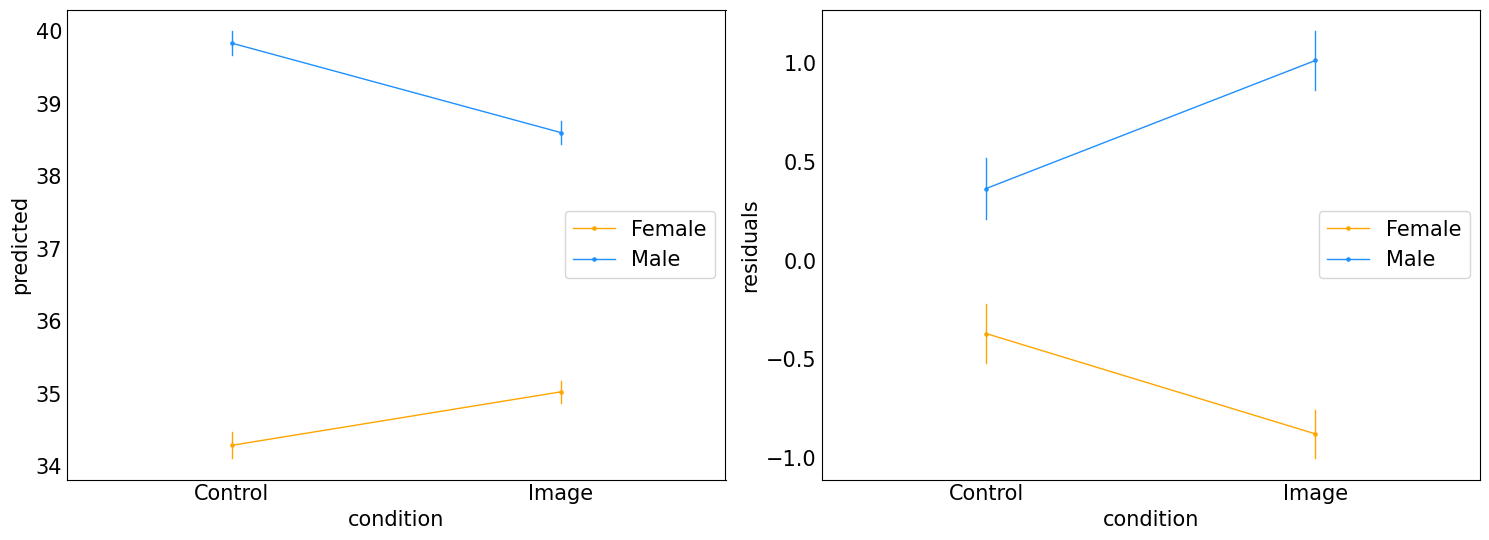

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

# Left plot: predicted values
sns.pointplot(
    data=combined_df, x='condition', y='predicted',
    hue='gender', order=['Control', 'Image'],
    hue_order=['Female', 'Male'],
    palette={'Male': 'dodgerblue', 'Female': 'orange'},
    capsize=0, errorbar='se', linewidth=1, ax=ax1
)
ax1.tick_params(axis='both', length=0, labelsize=15)
ax1.set_xlabel('condition', fontsize=15)
ax1.set_ylabel('predicted', fontsize=15)
ax1.legend(loc='center right', title='', fontsize=15)

# Right plot: residuals
sns.pointplot(
    data=combined_df, x='condition', y='residuals',
    hue='gender', order=['Control', 'Image'],
    hue_order=['Female', 'Male'],
    palette={'Male': 'dodgerblue', 'Female': 'orange'},
    capsize=0, errorbar='se', linewidth=1, ax=ax2
)
ax2.tick_params(axis='both', length=0, labelsize=15)
ax2.set_xlabel('condition', fontsize=15)
ax2.set_ylabel('residuals', fontsize=15)
ax2.legend(loc='center right', title='', fontsize=15)

plt.tight_layout()
plt.show()

The left plot shows the average age that the model expects based only on the occupation and the participant. Occupations that tend to be seen as female, like secretary or nurse, already have lower baseline ages than occupations seen as male, like military personnel or director. This pattern exists in both the Control and the Image condition and does not change much between them. The left plot is showing us the occupation level bias that was already there before the experiment even started.

The right plot tells a different story. It shows the residuals, which are the age estimates after removing what the occupation and the participant already explain. In the Control condition, participants who uploaded a male image estimated slightly higher ages than expected, and participants who uploaded a female image estimated slightly lower ages than expected. In the Image condition, this pattern gets stronger. The male residuals go up and the female residuals go down. The gap between the two lines grows.

This means that on top of the occupation level bias we see in the left plot, image search adds an extra push. People who are exposed to female images on Google estimate even younger ages than the occupation alone would suggest. People exposed to male images estimate even older ages. The two plots together show that the bias exists at two levels, one coming from the occupations themselves and one coming from the images that Google shows.

### ANOVA: Testing the Interaction

To test whether the condition by gender interaction is statistically significant, we run two ANOVA models with Sum (Type II) encoding.

Sum encoding compares each level of a variable to the grand mean rather than to a reference level. This makes the main effects interpretable even when an interaction is present in the model, because they represent the average effect across all groups rather than the effect at one specific reference level.

We run two versions of the model. The first one has no controls and tests the raw interaction between condition and gender. The second one adds occupation and participant as controls, which removes the noise coming from different occupations having different baseline ages and different participants having different tendencies. If the interaction is significant in the second model but not in the first, it means the effect only becomes visible once we remove those sources of noise. If it is significant in both, the finding is very robust.

In [29]:
from statsmodels.stats.anova import anova_lm

# ANOVA Model 1: condition * gender
model_anova1 = smf.ols(
    formula='age ~ C(condition, Sum) * C(gender, Sum)',
    data=combined_df
).fit()

anova1 = anova_lm(model_anova1, typ=2)
anova1

,sum_sq,df,F,PR(>F)
"C(condition, Sum)",57.586138,1.0,0.607880,4.356088e-01
"C(gender, Sum)",71856.913990,1.0,758.522619,5.017108e-160
"C(condition, Sum):C(gender, Sum)",347.367889,1.0,3.666820,5.553946e-02
Residual,806175.481608,8510.0,NaN,NaN


**Model 1 results** (no controls):

Gender has a very large effect on age estimates (F = 758.52, p < .001). People who uploaded a female image estimated significantly younger ages than those who uploaded a male image. This holds regardless of which condition they were in.

Condition on its own has no significant effect (F = 0.61, p = .44). Being in the image condition does not make people estimate older or younger ages in general. The effect of image search is not about shifting everyone's estimates up or down. It is about how it treats female and male images differently.

The interaction between condition and gender is marginal (F = 3.67, p = .056). It is very close to the significance threshold but does not quite reach it. This is expected because without controlling for which occupation is being rated and who is rating it, there is too much noise in the data to detect the effect clearly. This is why we need Model 2.

In [30]:
# ANOVA Model 2: condition * gender + for occupation and subject
model_anova2 = smf.ols(
    formula='age ~ C(condition, Sum) * C(gender, Sum) + category + subj',
    data=combined_df
).fit()

anova2 = anova_lm(model_anova2, typ=2)
anova2

,sum_sq,df,F,PR(>F)
"C(condition, Sum)",620.352248,1.0,13.649851,2.217273e-04
"C(gender, Sum)",8055.025507,1.0,177.237846,5.166031e-40
category,230669.638586,53.0,95.764404,0.000000e+00
subj,456023.489312,453.0,22.150246,0.000000e+00
"C(condition, Sum):C(gender, Sum)",329.073698,1.0,7.240736,7.141576e-03
Residual,363807.622227,8005.0,NaN,NaN


**Model 2 results** (with occupation and participant controls):

Gender is still highly significant (F = 177.24, p < .001). Even after accounting for which occupation is being rated and who is rating it, female images are still associated with younger age estimates than male images.

Condition is now also significant (F = 13.65, p < .001). Once we control for occupation and participant, being in the image condition does shift age estimates overall.

The interaction between condition and gender is now clearly significant (F = 7.24, p = .007). This is the key result and it directly matches what the article reports (β = -0.84, t = -2.69, p = .007).

The interaction was only marginal in Model 1 because the variation coming from different occupations and different participants was making it harder to see the condition by gender effect. Once we add occupation and participant as controls in Model 2 and account for their influence, the interaction between condition and gender becomes significant. This tells us that the age gap between female and male images grows when people are exposed to image search, and this is true regardless of which occupation is being rated and who is doing the rating.

### Conclusion

Across all our analyses, the same pattern emerges. GPT-2 links gender and age together in its representations of social categories, with female categories associated with younger ages and male categories with older ages. This bias is not just present in language models. It is also reflected in how people estimate ages after being exposed to Google Image search results. People who see female images estimate younger ages and people who see male images estimate older ages, and this gap is larger than what people believe without seeing any images at all. The amplification effect is statistically robust and holds even after accounting for which occupation is being rated and who is doing the rating. Taken together, our findings replicate the article's central claim that online image search does not just reflect existing stereotypes about age and gender, but it makes them stronger.